<a href="https://colab.research.google.com/github/diyajain0902/Malaria-Cell-Detection-using-CNN-with-Grad-CAM/blob/main/Malaria_Detection_Using_CNN_with_GradCAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import json, os

kaggle_config = {
    "username": "vanshika12k",
    "key": "ea6f6ac70a300c63e3b98888aaf785a6"
}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle ready!")

Kaggle ready!


In [ ]:
!pip install kaggle -q
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria
!unzip cell-images-for-detecting-malaria.zip -d malaria_data
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
cell-images-for-detecting-malaria.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  cell-images-for-detecting-malaria.zip
replace malaria_data/cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

base_dir = 'malaria_data/cell_images/cell_images'

for folder in os.listdir(base_dir):
    path = os.path.join(base_dir, folder)
    if os.path.isdir(path):
        print(f"{folder}: {len(os.listdir(path))} images")

Uninfected: 13780 images
Parasitized: 13780 images


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)
print("All libraries imported!")

TensorFlow version: 2.19.0
All libraries imported!


In [ ]:
IMG_SIZE = 64  # resize all images to 64x64
BATCH_SIZE = 32

base_dir = 'malaria_data/cell_images/cell_images'

images = []
labels = []

# 0 = Uninfected, 1 = Parasitized
class_map = {'Uninfected': 0, 'Parasitized': 1}

for class_name, label in class_map.items():
    folder_path = os.path.join(base_dir, class_name)
    files_list = os.listdir(folder_path)
    print(f"Loading {class_name}... ({len(files_list)} images)")

    for file_name in files_list:
        if file_name.endswith('.png') or file_name.endswith('.jpg'):
            img_path = os.path.join(folder_path, file_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)
                labels.append(label)

# Convert to numpy arrays
images = np.array(images, dtype='float32') / 255.0  # normalize to 0-1
labels = np.array(labels)

print(f"\nTotal images loaded: {len(images)}")
print(f"Image shape: {images[0].shape}")
print(f"Labels: {np.unique(labels, return_counts=True)}")

Loading Uninfected... (13780 images)
Loading Parasitized... (13780 images)

Total images loaded: 27558
Image shape: (64, 64, 3)
Labels: (array([0, 1]), array([13779, 13779]))


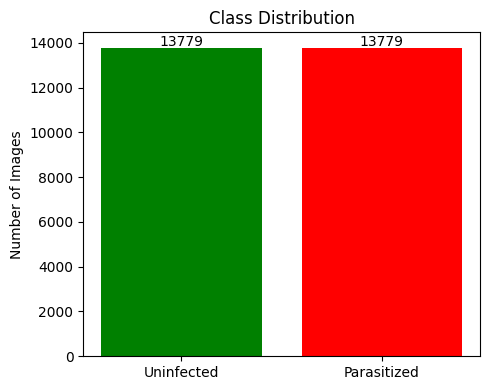

In [ ]:
plt.figure(figsize=(5, 4))
classes = ['Uninfected', 'Parasitized']
counts = [np.sum(labels == 0), np.sum(labels == 1)]
plt.bar(classes, counts, color=['green', 'red'])
plt.title('Class Distribution')
plt.ylabel('Number of Images')
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

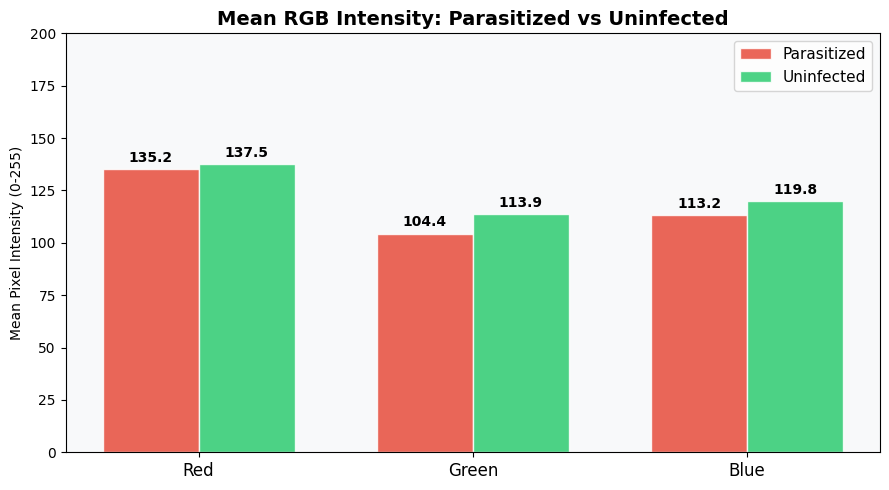

In [ ]:
import random
from PIL import Image

# Your actual paths and file lists
INFECTED_DIR   = 'malaria_data/cell_images/cell_images/Parasitized'
UNINFECTED_DIR = 'malaria_data/cell_images/cell_images/Uninfected'

infected_images   = [f for f in os.listdir(INFECTED_DIR)   if f.endswith('.png') or f.endswith('.jpg')]
uninfected_images = [f for f in os.listdir(UNINFECTED_DIR) if f.endswith('.png') or f.endswith('.jpg')]

def mean_rgb(image_list, folder, n=300):
    r_means, g_means, b_means = [], [], []
    for fname in random.sample(image_list, min(n, len(image_list))):
        img = np.array(Image.open(os.path.join(folder, fname)).resize((64, 64)))
        if img.ndim == 3:
            r_means.append(img[:,:,0].mean())
            g_means.append(img[:,:,1].mean())
            b_means.append(img[:,:,2].mean())
    return np.mean(r_means), np.mean(g_means), np.mean(b_means)

inf_rgb = mean_rgb(infected_images,   INFECTED_DIR)
uni_rgb = mean_rgb(uninfected_images, UNINFECTED_DIR)

channels_names = ['Red', 'Green', 'Blue']
x = np.arange(len(channels_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, inf_rgb, width, label='Parasitized', color='#E74C3C', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, uni_rgb, width, label='Uninfected',  color='#2ECC71', alpha=0.85, edgecolor='white')

ax.set_title('Mean RGB Intensity: Parasitized vs Uninfected', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Pixel Intensity (0-255)')
ax.set_xticks(x)
ax.set_xticklabels(channels_names, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 200)
ax.set_facecolor('#f8f9fa')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2, f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

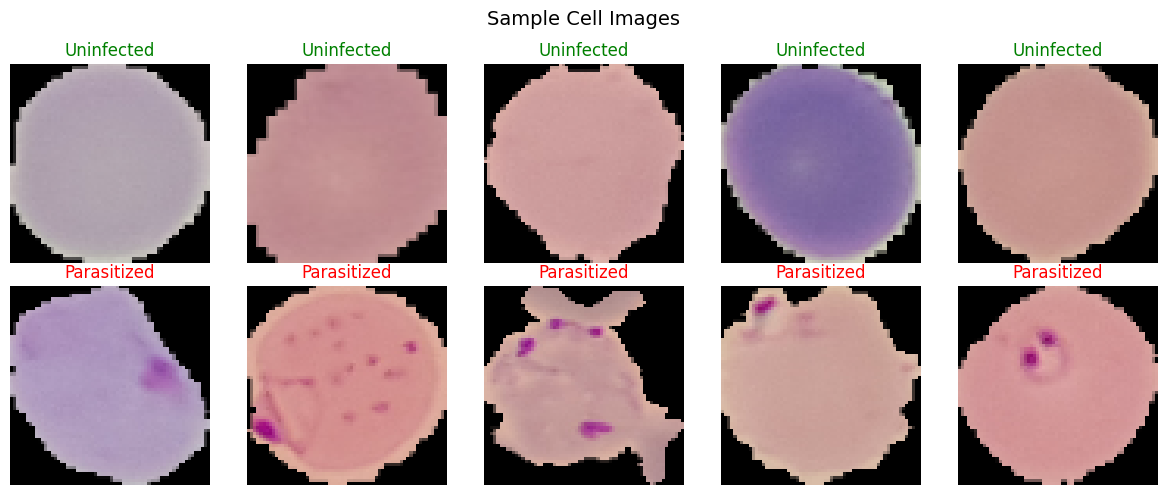

In [ ]:
plt.figure(figsize=(12, 5))

# Show 5 uninfected
for i in range(5):
    idx = np.where(labels == 0)[0][i]
    plt.subplot(2, 5, i+1)
    plt.imshow(images[idx])
    plt.title("Uninfected", color='green')
    plt.axis('off')

# Show 5 parasitized
for i in range(5):
    idx = np.where(labels == 1)[0][i]
    plt.subplot(2, 5, i+6)
    plt.imshow(images[idx])
    plt.title("Parasitized", color='red')
    plt.axis('off')

plt.suptitle("Sample Cell Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.30, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")

Training samples:   19290
Validation samples: 4134
Test samples:       4134


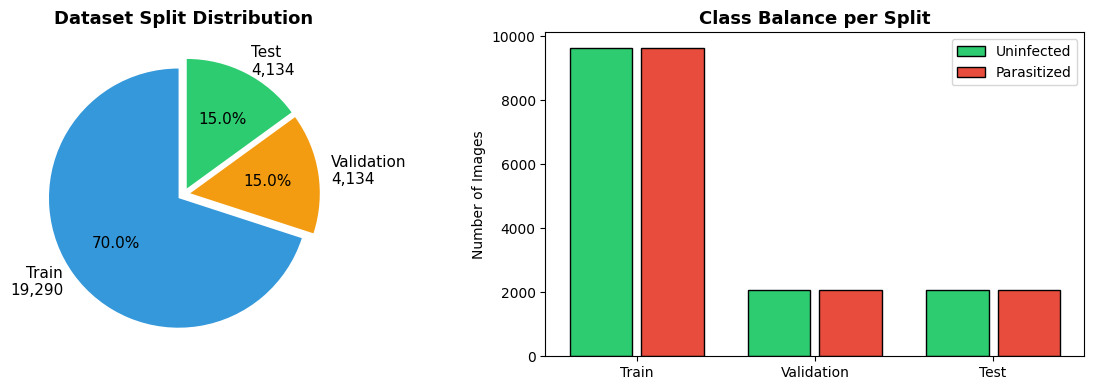

In [ ]:
# GRAPH 3: Dataset Split Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
sizes = [len(X_train), len(X_val), len(X_test)]
labels_pie = [f'Train\n{len(X_train):,}', f'Validation\n{len(X_val):,}', f'Test\n{len(X_test):,}']
colors = ['#3498db', '#f39c12', '#2ecc71']
explode = (0.05, 0.05, 0.05)

axes[0].pie(sizes, labels=labels_pie, colors=colors, explode=explode,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Dataset Split Distribution', fontsize=13, fontweight='bold')

# Bar chart showing class balance within each split
splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test}
x = np.arange(3)
uninf_counts = [np.sum(y == 0) for y in splits.values()]
para_counts  = [np.sum(y == 1) for y in splits.values()]

axes[1].bar(x - 0.2, uninf_counts, 0.35, label='Uninfected', color='#2ecc71', edgecolor='black')
axes[1].bar(x + 0.2, para_counts,  0.35, label='Parasitized', color='#e74c3c', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Train', 'Validation', 'Test'])
axes[1].set_title('Class Balance per Split', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Images')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Augmentation only on training data to make model more robust
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)
print("Data augmentation ready!")

Data augmentation ready!


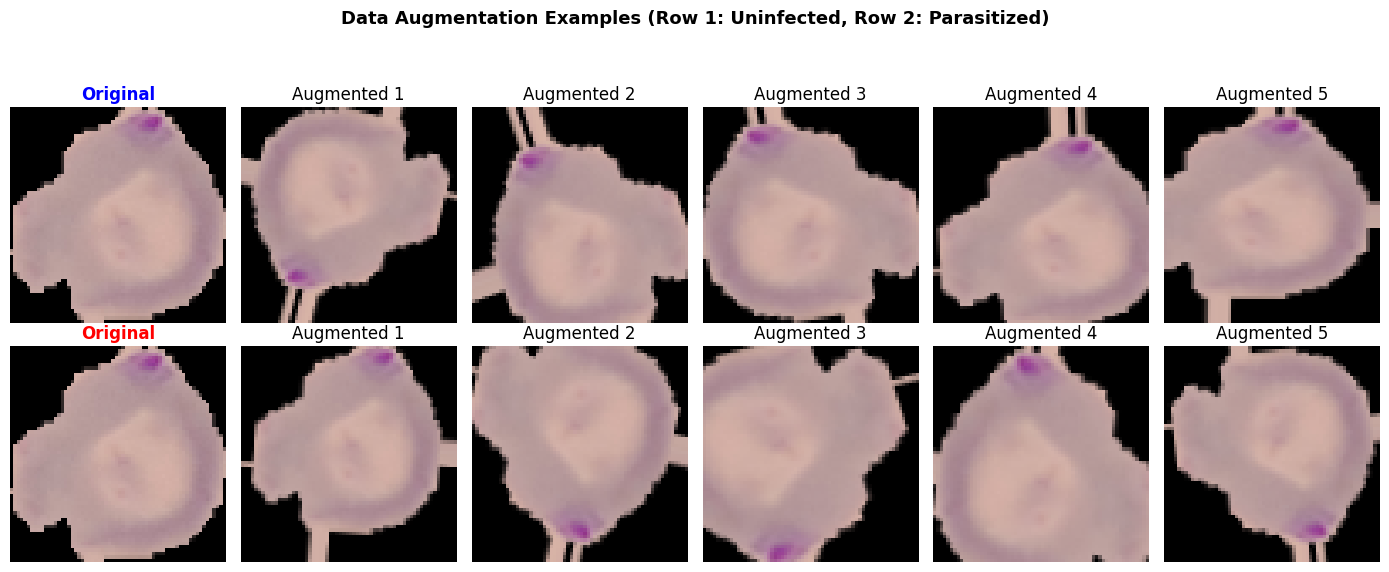

In [ ]:
# GRAPH 4: Augmentation Examples
fig, axes = plt.subplots(2, 6, figsize=(14, 6))

sample_img = X_train[0:1]  # take one image

axes[0, 0].imshow(X_train[0])
axes[0, 0].set_title('Original', fontweight='bold', color='blue')
axes[0, 0].axis('off')

# Generate 5 augmented versions
aug_gen = datagen.flow(sample_img, batch_size=1)
for j in range(1, 6):
    aug_img = next(aug_gen)[0]
    axes[0, j].imshow(aug_img)
    axes[0, j].set_title(f'Augmented {j}')
    axes[0, j].axis('off')

# Do the same for a parasitized image
parasitized_idx = np.where(y_train == 1)[0][0]
sample_para = X_train[parasitized_idx:parasitized_idx+1]

axes[1, 0].imshow(X_train[parasitized_idx])
axes[1, 0].set_title('Original', fontweight='bold', color='red')
axes[1, 0].axis('off')

aug_gen2 = datagen.flow(sample_para, batch_size=1)
for j in range(1, 6):
    aug_img = next(aug_gen2)[0]
    axes[1, j].imshow(aug_img)
    axes[1, j].set_title(f'Augmented {j}')
    axes[1, j].axis('off')

plt.suptitle('Data Augmentation Examples (Row 1: Uninfected, Row 2: Parasitized)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect = [0,0,1,0.93])
plt.show()

In [ ]:
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Flatten and Dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # prevents overfitting
    Dense(1, activation='sigmoid')  # binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,977 (4.36 MB)

 Trainable params: 1,142,529 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Stop early if model stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

print("Training complete!")

Epoch 1/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.8145 - loss: 0.4469 - val_accuracy: 0.9173 - val_loss: 0.2221
Epoch 2/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.9321 - loss: 0.2227 - val_accuracy: 0.9168 - val_loss: 0.2862
Epoch 3/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.9388 - loss: 0.2037 - val_accuracy: 0.9299 - val_loss: 0.2160
Epoch 4/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - accuracy: 0.9427 - loss: 0.1847 - val_accuracy: 0.9475 - val_loss: 0.1575
Epoch 5/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9455 - loss: 0.1741 - val_accuracy: 0.9354 - val_loss: 0.1912
Epoch 6/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9481 - loss: 0.1720 - val_accuracy: 0.9504 - val_loss: 0.1475
Epoch 7/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9500 - loss: 0.1630 - val_accuracy: 0.9504 - val_loss: 0.1456
Epoch 8/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.9505 - loss: 0.1596 - 

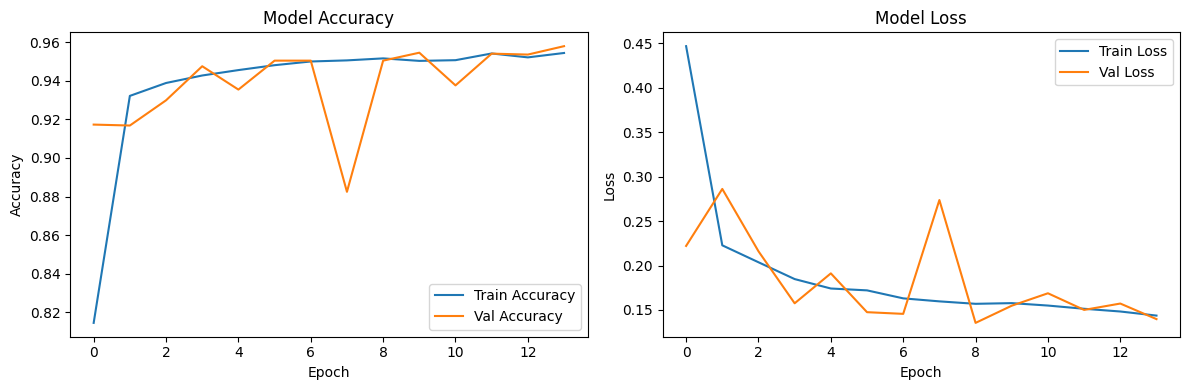

In [ ]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

# Detailed report
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Uninfected', 'Parasitized']))

Test Accuracy: 95.60%
Test Loss:     0.1292
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.94      0.98      0.96      2067
 Parasitized       0.98      0.93      0.95      2067

    accuracy                           0.96      4134
   macro avg       0.96      0.96      0.96      4134
weighted avg       0.96      0.96      0.96      4134



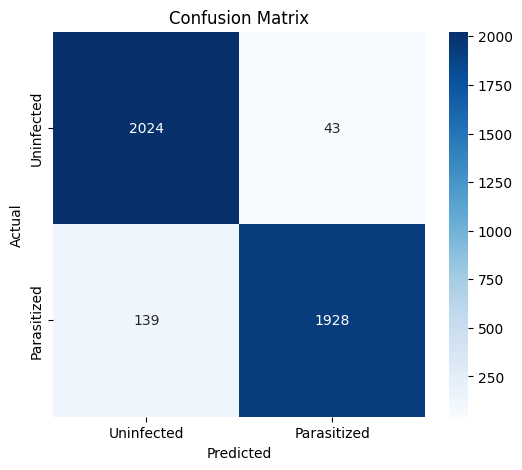

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

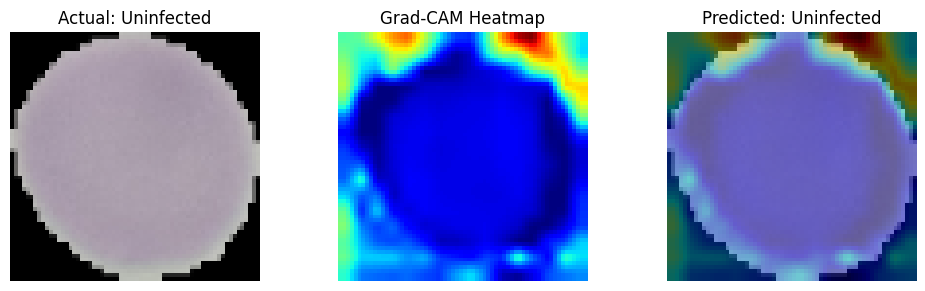

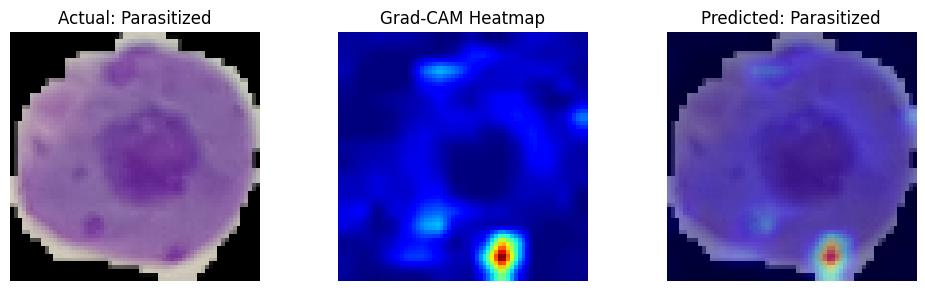

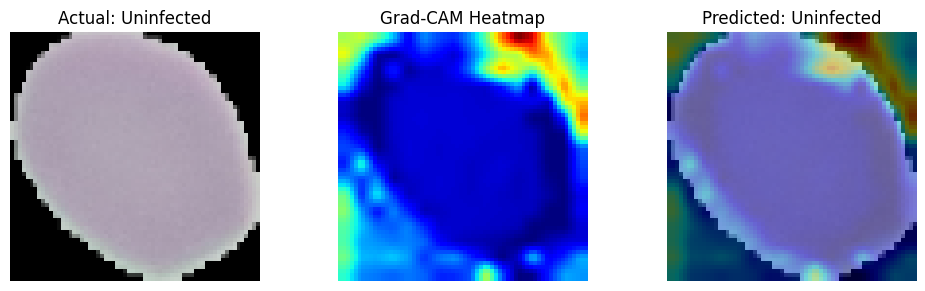

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

# Fix: rebuild grad_cam compatible model by running a dummy prediction first
_ = model.predict(X_test[:1], verbose=0)

def get_gradcam_heatmap(model, image):
    last_conv_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer.name

    # Build a new functional model from scratch using same weights
    inp = tf.keras.Input(shape=(64, 64, 3))
    x = inp
    conv_out = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer:
            conv_out = x

    grad_model = tf.keras.Model(inputs=inp, outputs=[conv_out, x])

    img_array = tf.cast(np.expand_dims(image, axis=0), tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam(model, image, actual_label, pred_label):
    try:
        heatmap = get_gradcam_heatmap(model, image)
        heatmap_resized = cv2.resize(heatmap, (64, 64))
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        superimposed = (heatmap_colored / 255.0) * 0.4 + image * 0.6

        plt.figure(figsize=(10, 3))
        plt.subplot(1, 3, 1)
        plt.imshow(image)
        plt.title(f"Actual: {'Parasitized' if actual_label==1 else 'Uninfected'}")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(heatmap_resized, cmap='jet')
        plt.title("Grad-CAM Heatmap")
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(superimposed)
        plt.title(f"Predicted: {'Parasitized' if pred_label==1 else 'Uninfected'}")
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error on sample: {e}")

# Show Grad-CAM for 3 test samples
for i in range(3):
    show_gradcam(model, X_test[i], y_test[i], y_pred[i])

In [ ]:
model.save('malaria_cnn_model.keras')
print("Model saved!")

Model saved!


In [ ]:
model.save('malaria_cnn_model.keras')

from google.colab import files
files.download('malaria_cnn_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>